In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

import sys
sys.path.append("/mnt/d/Users/Admin/Projects/dso/learnable_polyphase_sampling/learn_poly_sampling")

from functools import partial
from layers import PolyphaseInvariantDown2D, LPS, get_logits_model
from models.resnet_custom import ResNet18Custom

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"

In [4]:
meas_ds = DatasetFolderWithPath(
    os.path.join(workspace, "data/DSO/mstar/npy_noscaling_files/real"),
    extensions=(".npy"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        NumpyToTensor3Channel()
    ]),
    loader=dso_np_file_loader
)

In [5]:
def obtain_mask_from_tiff_flipped(path, values = [65, 67, 193, 195, 225, 227]):
    with TiffFile(path) as tif:
        mask = tif.pages[3].asarray()
    mask = np.fliplr(mask)
    return np.isin(mask, values)

class QuantileBackground:
    def __init__(self, clutter_cache, mask_cache, preloaded=None, crop_size=128, c=1000.0,
                 percentile=70, clip=False, debug=False):
        self.clutter_cache = clutter_cache
        self.mask_cache = mask_cache
        self.preloaded = preloaded
        self.crop_size = crop_size
        self.log_mapper = LogMapping(c=c)
        self.percentile = percentile
        self.clip = clip
        self.debug = debug

    def __call__(self, img_or_tuple):
        if isinstance(img_or_tuple, tuple):
            I_meas, filepath = img_or_tuple
        else:
            return img_or_tuple

        abs_path = str(Path(filepath).resolve())
        if abs_path not in self.clutter_cache:
            print(f"WARNING: {filepath} not in clutter cache!")
            return I_meas
        if abs_path not in self.mask_cache:
            print(f"WARNING: {filepath} not in mask cache!")
            return (I_meas, filepath)

        clutter_file, r, c = self.clutter_cache[abs_path]

        if self.preloaded and clutter_file in self.preloaded:
            clutter_log = self.preloaded[clutter_file]
        else:
            clutter_complex = read_mstar_clutter_complex(clutter_file)
            clutter_raw = Magnitude()(clutter_complex)
            clutter_log = self.log_mapper(clutter_raw)

        C = clutter_log[r:r + self.crop_size, c:c + self.crop_size]

        M_fg = self.mask_cache[abs_path].astype(bool)   # already {0,1} -> just cast, no isin
        M_bg = ~M_fg

        fg_mean = I_meas[M_fg].mean()
        bg_p = np.percentile(C[M_bg], self.percentile)
        d = fg_mean - bg_p

        C_new = C + d
        I_merged = np.where(M_fg, I_meas, C_new)

        if self.clip:
            I_merged = np.clip(I_merged, 0.0, 1.0)
        I_merged = I_merged.astype(np.float32)

        if self.debug:
            print(f"{Path(filepath).name}: fg_mean={fg_mean:.4f}, bg_p{self.percentile}={bg_p:.4f}, d={d:.4f}, "
                  f"bg range=[{I_merged[M_bg].min():.4f}, {I_merged[M_bg].max():.4f}]")

        return (I_merged, filepath)

class MinMaxRescale:
    def __call__(self, data_or_tuple):
        if isinstance(data_or_tuple, tuple):
            data, filepath = data_or_tuple
            pass_along = True
        else:
            data = data_or_tuple
            filepath = None
            pass_along = False

        mn, mx = data.min(), data.max()
        if mx == mn:
            rescaled = np.zeros_like(data, dtype=np.float32)
        else:
            rescaled = (data - mn) / (mx - mn)
        rescaled = rescaled.astype(np.float32)

        return (rescaled, filepath) if pass_along else rescaled

def build_gmm_cache_from_dataset(dataset):
    gmm_cache = {}
    for i in tqdm(range(len(dataset)), desc="Fitting GMMs on images"):
        path = dataset.samples[i][0]
        processed_img = dataset[i][0][0].numpy()  # grab one channel, convert to numpy

        gmm_paras = fit_gmm_for_image(processed_img)

        abs_path = str(Path(path).resolve())
        gmm_cache[abs_path] = gmm_paras
    return gmm_cache

In [6]:
no_aug_synth_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26",
    extensions=(".tif",),
    transform=transforms.Compose([Magnitude(), LogMapping(c=1000.0), NumpyToTensor3Channel()]),
    loader=dso_tiff_file_loader_fast_flipped
)

synth_paths = [s[0] for s in no_aug_synth_ds.samples]
synth_cache = {}

for path in tqdm(synth_paths):
    mask = obtain_mask_from_tiff_flipped(path)
    synth_cache[path] = mask.astype(np.uint8)

synth_cache_cropped = {}
for path, mask in synth_cache.items():
    h, w = mask.shape
    t = 128
    top, left = (h - t) // 2, (w - t) // 2
    synth_cache_cropped[path] = mask[top:top+t, left:left+t]

clutter_dir = "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/MSTAR/CLUTTER/15_DEG"
clutter_cache = {file: (os.path.join(clutter_dir, 'HB06158'), 100, 100) for file in synth_paths}

clutter_path = os.path.join(clutter_dir, 'HB06158')
clutter_complex = read_mstar_clutter_complex(clutter_path)
clutter_log_full = LogMapping(c=1000.0)(Magnitude()(clutter_complex))

preloaded = {clutter_path: clutter_log_full}

merged_synth_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26",
    extensions=(".tif",),
    transform=transforms.Compose([
        Magnitude(),
        CenterCrop(128),
        LogMapping(c=1000.0),
        QuantileBackground(
            clutter_cache=clutter_cache,
            preloaded=preloaded,
            mask_cache=synth_cache_cropped,
            crop_size=128,
            percentile=70,
            clip=False,
            debug=False,
        ),
        MinMaxRescale(),
        NumpyToTensor3Channel()
    ]),
    loader=dso_tiff_file_loader_fast_flipped
)

merged_gmm_cache = build_gmm_cache_from_dataset(merged_synth_ds)

SSR_merged_synth_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26",
        extensions=(".tif",),
        transform=transforms.Compose([
            Magnitude(),
            CenterCrop(128),
            LogMapping(c=1000.0),
            QuantileBackground(
                clutter_cache=clutter_cache,
                preloaded=preloaded,
                mask_cache=synth_cache_cropped,
                crop_size=128,
                percentile=70,
                clip=False,
                debug=False,
            ),
            MinMaxRescale(),
            SSRAugmentation(gmm_cache=merged_gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3),
            NumpyToTensor3Channel()
        ]),
        loader=dso_tiff_file_loader_fast_flipped
    )

Fitting GMMs on images: 100%|███████████████████████████████████████████████████████| 3600/3600 [07:19<00:00,  8.18it/s]


In [26]:
meas_ds.classes

['2s1',
 'bmp2',
 'brdm_2',
 'btr_60',
 'btr_70',
 'd7',
 't62',
 't72',
 't72_a04',
 't72_a05',
 't72_a07',
 't72_a10',
 't72_a32',
 't72_a62',
 't72_a63',
 't72_a64',
 'zil131',
 'zsu_23_4']

In [27]:
SSR_merged_synth_ds.classes

['BRDM2_X3230gz15sqp00',
 'T62_X3230gz15sqp00',
 'ZIL131_X3230gz15sqp00',
 'ZSU234_X3230gz15sqp00',
 'old_ZSU-23-4_X3230gz15sqp00']

In [28]:
train_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(SSR_merged_synth_ds, {14, 15, 16}), list(range(281, 351, 1))), 
    exclude_label= 4)

valid_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(meas_ds, {14, 15, 16}), list(range(10, 80, 1))),
    exclude_label= {0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15})
                          
test_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(meas_ds, {17}), list(range(10, 80, 1))),
    exclude_label= {0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15})

ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

In [29]:
dataset_sizes

{'train': 560, 'val': 243, 'test': 234}

In [30]:
train_ds.classes, valid_ds.classes, test_ds.classes

(['BRDM2_X3230gz15sqp00',
  'T62_X3230gz15sqp00',
  'ZIL131_X3230gz15sqp00',
  'ZSU234_X3230gz15sqp00'],
 ['brdm_2', 't62', 'zil131', 'zsu_23_4'],
 ['brdm_2', 't62', 'zil131', 'zsu_23_4'])

In [31]:
test_ds.samples

[('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_010_sn_e-71.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_011_sn_e-71.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_012_sn_e-71.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_013_sn_e-71.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_014_sn_e-71.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_015_sn_e-71.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_01

In [32]:
test_ds.samples[10]

('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_020_sn_e-71.npy',
 0)

In [33]:
np.unique(test_ds[10][0][0])

array([0.0000000e+00, 1.2855840e-16, 4.1781478e-16, 6.4279197e-16,
       2.0890740e-15, 3.0854014e-15, 8.0599792e-02, 8.0599800e-02,
       1.3206553e-01, 1.6995451e-01, 1.6995452e-01, 1.9995485e-01,
       1.9995487e-01, 2.2479205e-01, 2.2479206e-01, 2.4598502e-01,
       2.4598503e-01, 2.6446763e-01, 2.8085515e-01, 2.9557458e-01,
       3.0893433e-01, 3.0893436e-01, 3.2116452e-01, 3.2116455e-01,
       3.3244136e-01, 3.3244139e-01, 3.4290278e-01, 3.4290281e-01,
       3.5265878e-01, 3.5265881e-01, 3.6179855e-01, 3.7039530e-01,
       3.7850994e-01, 3.7850997e-01, 3.8619372e-01, 3.8619375e-01,
       3.9349011e-01, 3.9349014e-01, 4.0043625e-01, 4.0043628e-01,
       4.0706426e-01, 4.0706429e-01, 4.1340202e-01, 4.1340205e-01,
       4.1947389e-01, 4.1947392e-01, 4.2530125e-01, 4.3090305e-01,
       4.3090308e-01, 4.3629614e-01, 4.4149545e-01, 4.4651446e-01,
       4.5136523e-01, 4.5136526e-01, 4.5605874e-01, 4.5605877e-01,
       4.6060479e-01, 4.6060482e-01, 4.6501240e-01, 4.6501243e

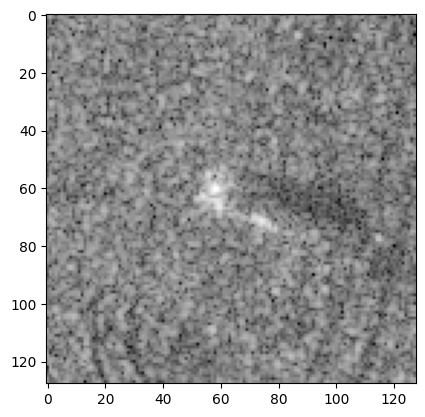

In [34]:
plt.imshow(test_ds[10][0][0].numpy(), cmap='gray', vmin = 0, vmax = 1)

In [35]:
test_ds[10][0][0].numpy().shape

(128, 128)

In [36]:
train_ds.samples

[('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp281f_X3230gz15sqp00_dispimg_fdf6d9968.tif',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp281g_X3230gz15sqp00_dispimg_fdf6d9968.tif',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp282f_X3230gz15sqp00_dispimg_fdf6d9968.tif',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp282g_X3230gz15sqp00_dispimg_fdf6d9968.tif',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp283f_X3230gz15sqp00_dispimg_fdf6d9968.tif',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp283g_X3230gz15sqp00_dispimg_fdf6d9968.tif',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp284f_X3230gz15sqp00_d

In [37]:
train_ds.samples[118]

('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp340f_X3230gz15sqp00_dispimg_fdf6d9968.tif',
 0)

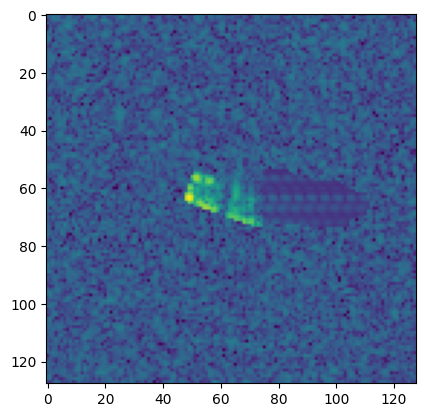

In [38]:
plt.imshow(train_ds[118][0][0].numpy(), vmin = 0, vmax = 1)

In [39]:
train_ds[118][0][0].numpy().shape

(128, 128)

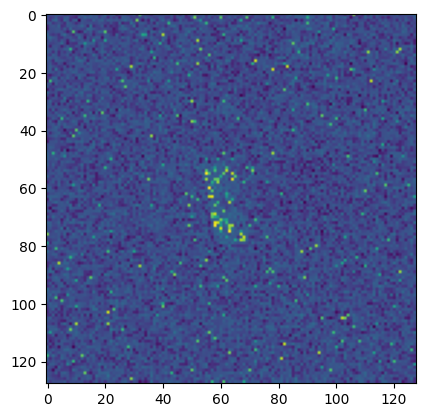

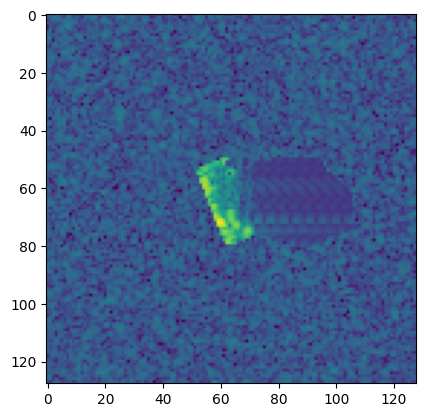

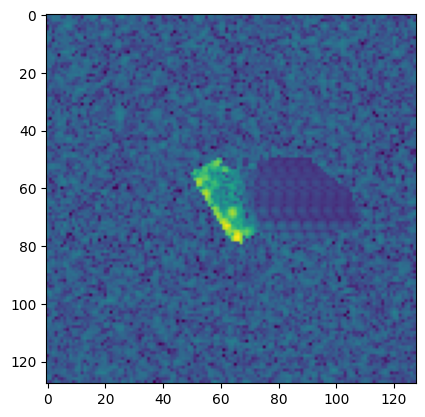

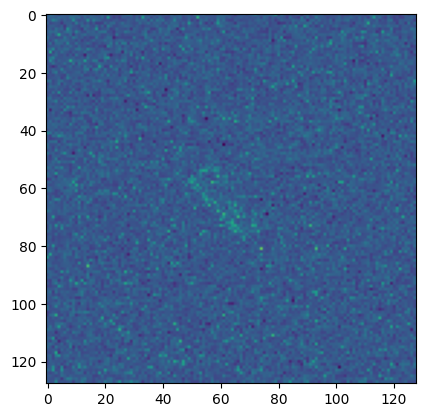

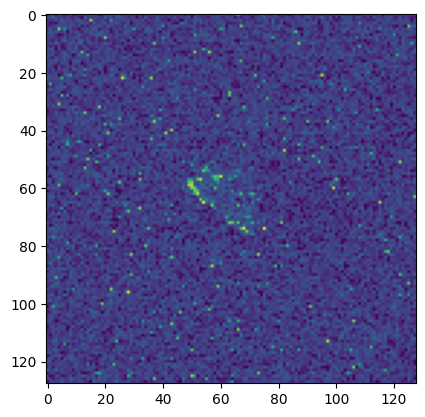

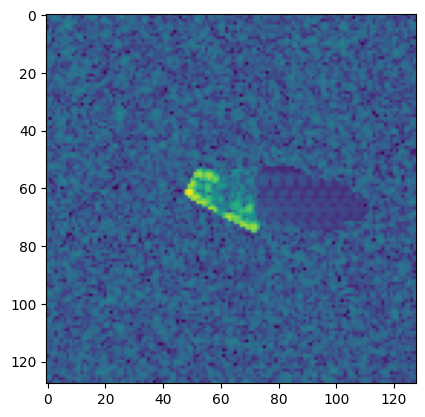

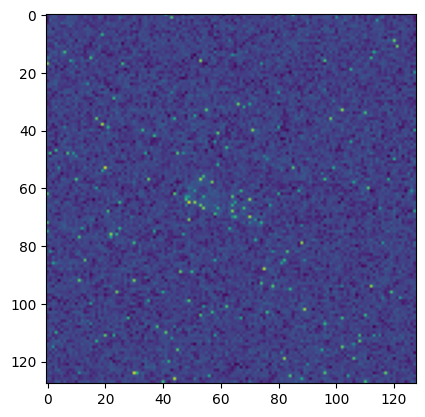

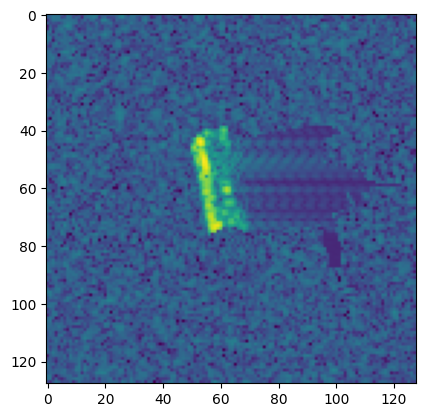

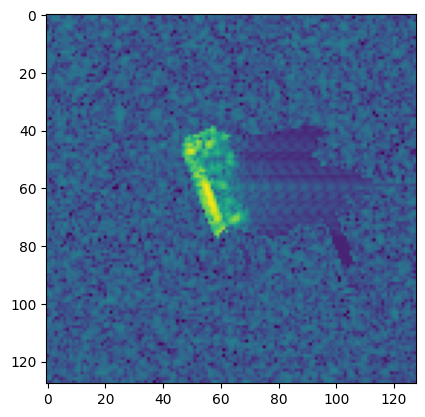

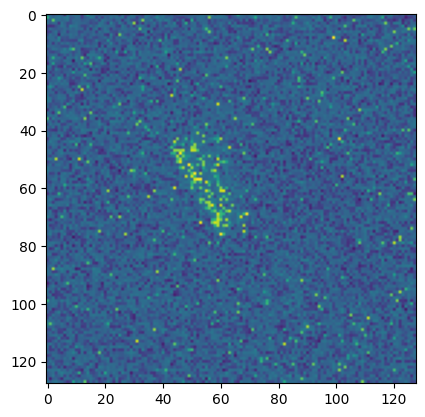

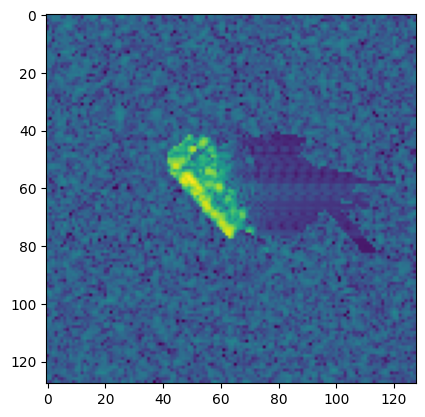

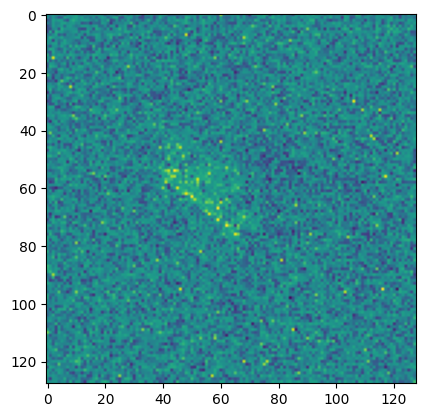

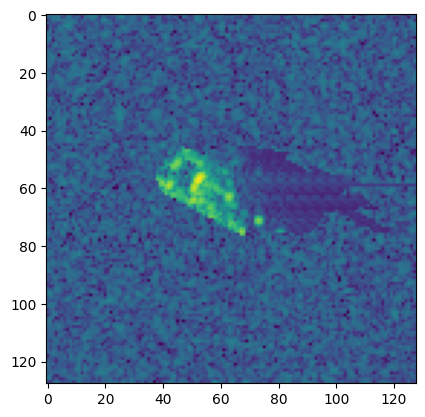

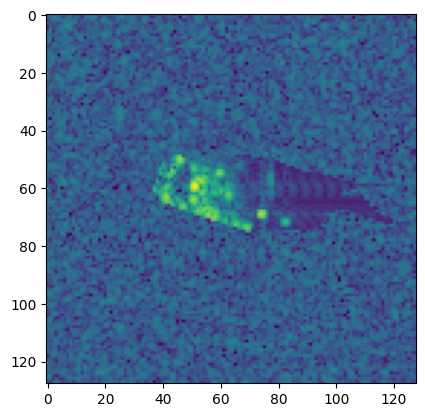

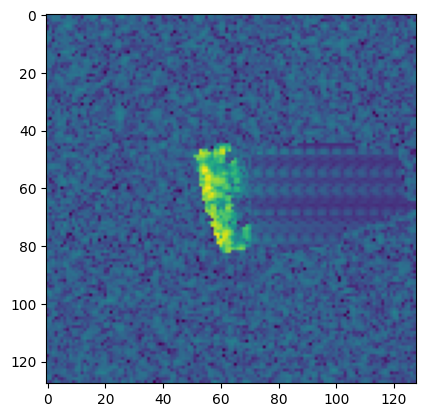

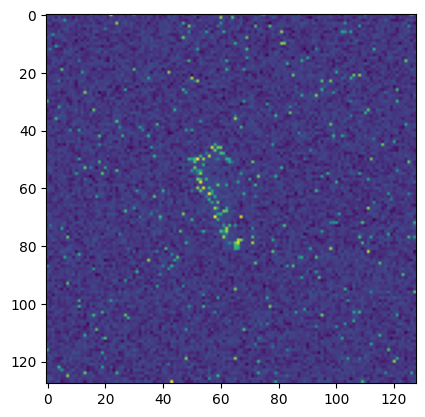

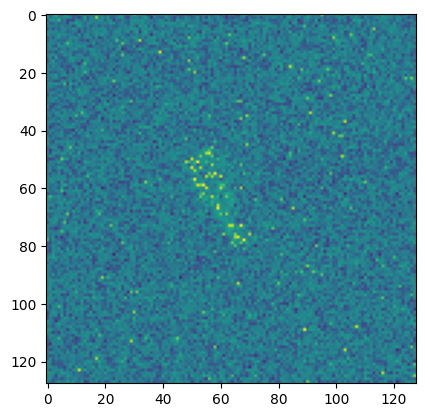

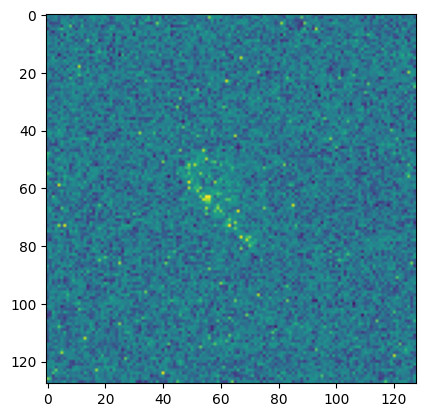

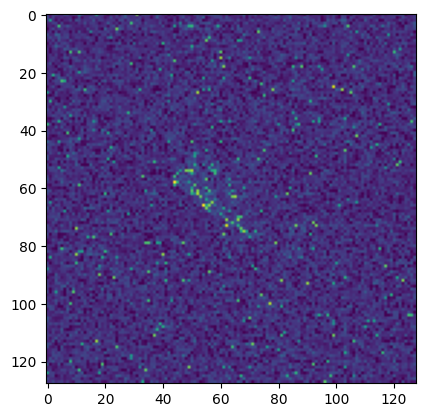

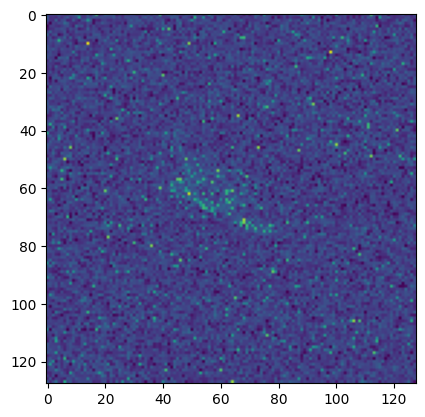

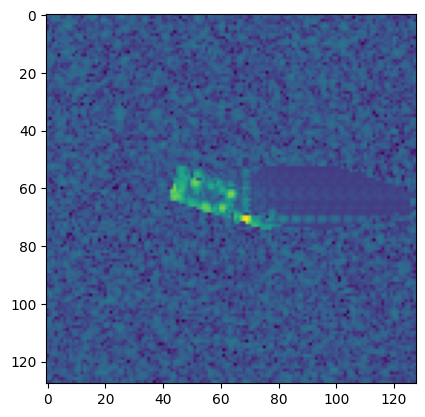

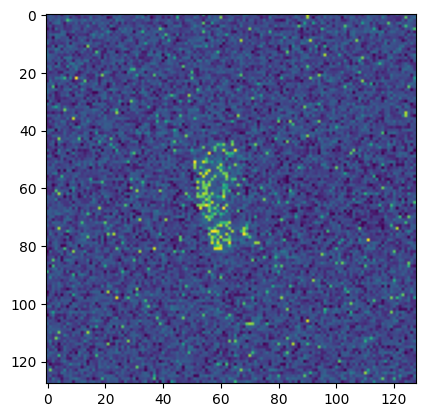

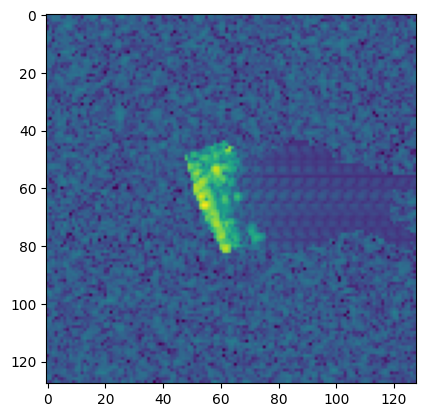

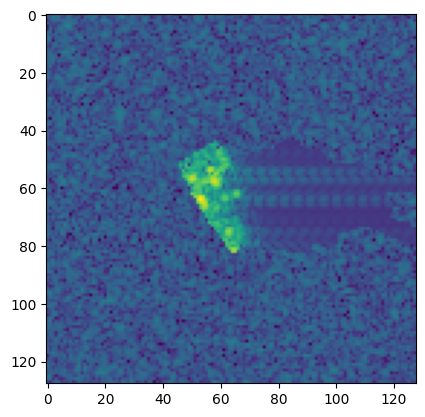

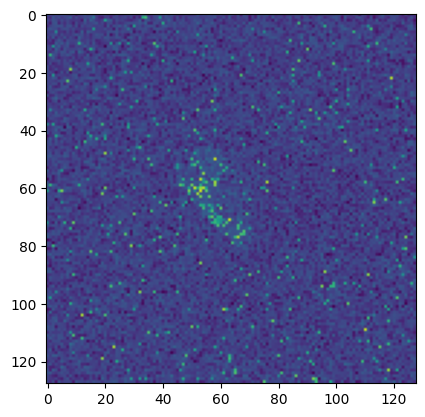

In [40]:
for i in range(0, 500, 20):
    plt.imshow(train_ds[i][0][0].numpy(), vmin = 0, vmax = 1)
    plt.show()

In [41]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
 
train_loss = []
val_loss = []
train_acc = []
val_acc = []
 
for i, seed in enumerate(seed_lst):
    
    start = time.perf_counter()
    
    print(f"Training Run {i}: seed {seed}")
    set_seed(seed)
 
    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
    get_logits = get_logits_model('LPSLogitLayers')
    pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)
    extras_model = {
        'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
        'conv1_stride': False,
        'maxpool_zpad': False,
        'swap_conv_pool': True,
        'inc_conv1_support': True,
        'apply_maxpool': True,
        'ret_prob': True,
        'forward_pool_method': 'LPS',
    }
    
    model = ResNet18Custom(
        input_shape=(3, 128, 128),
        num_classes=len(train_ds.class_to_idx),
        padding_mode='circular',
        pooling_layer=pooling_layer,
        extras_model=extras_model,
    )
 
    # Define the loss function and optimizer
    criterion = nn.NLLLoss()

    net_pars, pool_pars = [], []
    for n, p in model.named_parameters():
        if "component_selection" in n and p.requires_grad:
            pool_pars.append(p)
        elif p.requires_grad:
            net_pars.append(p)
            
    optimizer = optim.AdamW([
        {"params": net_pars, "weight_decay": 2e-4},
        {"params": pool_pars, "weight_decay": 0},
    ], lr=3e-4)
    
    scheduler = CosineAnnealingLR(optimizer, T_max=200, eta_min=3e-7)
    
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
 
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }
 
    # Training loop
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.core.conv1.weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
 
            running_loss = 0.0
            running_corrects = 0
 
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
 
                optimizer.zero_grad()
 
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
 
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
 
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
 
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
 
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
 
            print(f"{phase} Loss: {epoch_loss:.10f} Acc: {epoch_acc:.10f}")
 
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
 
    print("Training complete!")
 
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
 
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/dso_data/new_data/full_image/SSR_w_noise/rn18_seed{seed}_b16_theirmodel.pth"))
    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")
 
train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0: seed 10
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Epoch 0
First layer mean: 0.000035
train Loss: 1.6138677291 Acc: 0.3553571429
val Loss: 1.3307348240 Acc: 0.3004115226
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 1.2285164561 Acc: 0.4410714286
val Loss: 3.6127328622 Acc: 0.2633744856
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 1.2062472548 Acc: 0.4625000000
val Loss: 6.8207652926 Acc: 0.2510288066
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 1.0826025282 Acc: 0.4982142857
val Loss: 9.3104900250 Acc: 0.2921810700
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.9533533420 Acc: 0.5785714286
val Loss: 5.8294905271 Acc: 0.2510288066
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.7584889735 Acc: 0.6803571429
val Loss: 2.0262848144 Acc: 0.2839506173
Epoch 5

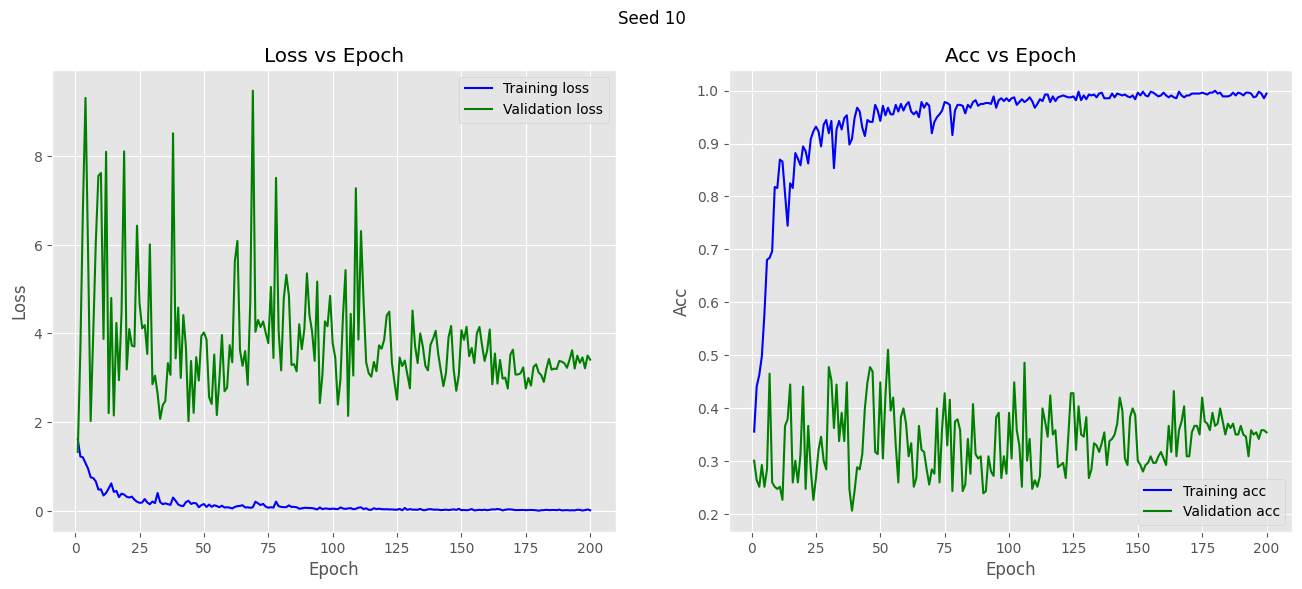

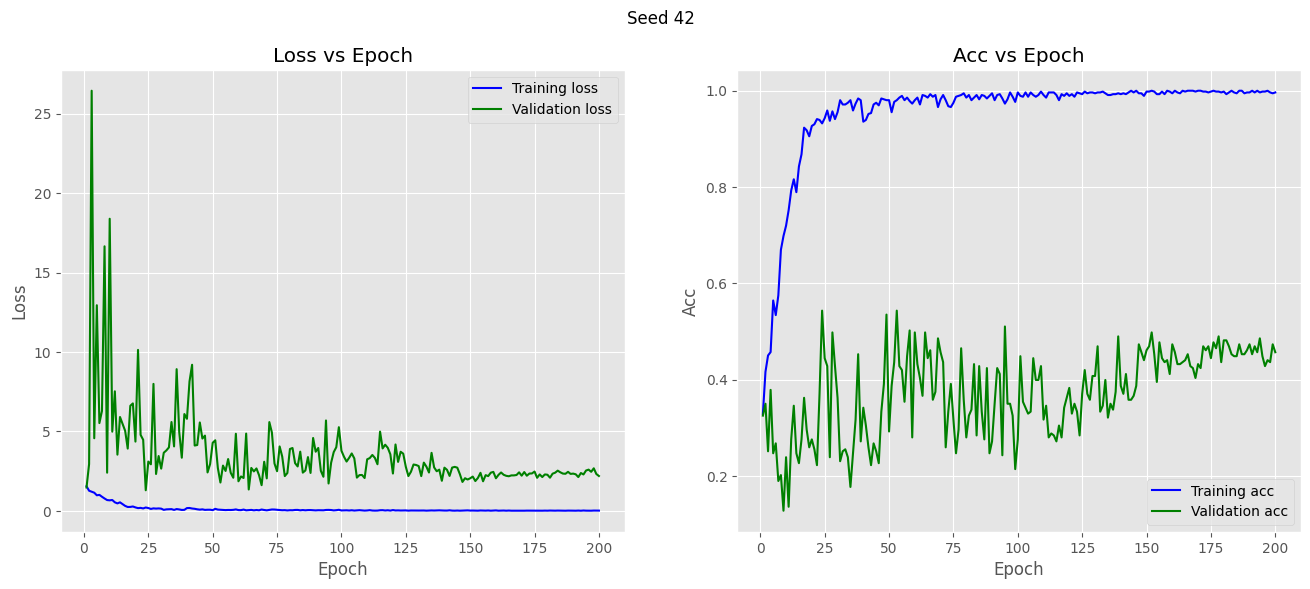

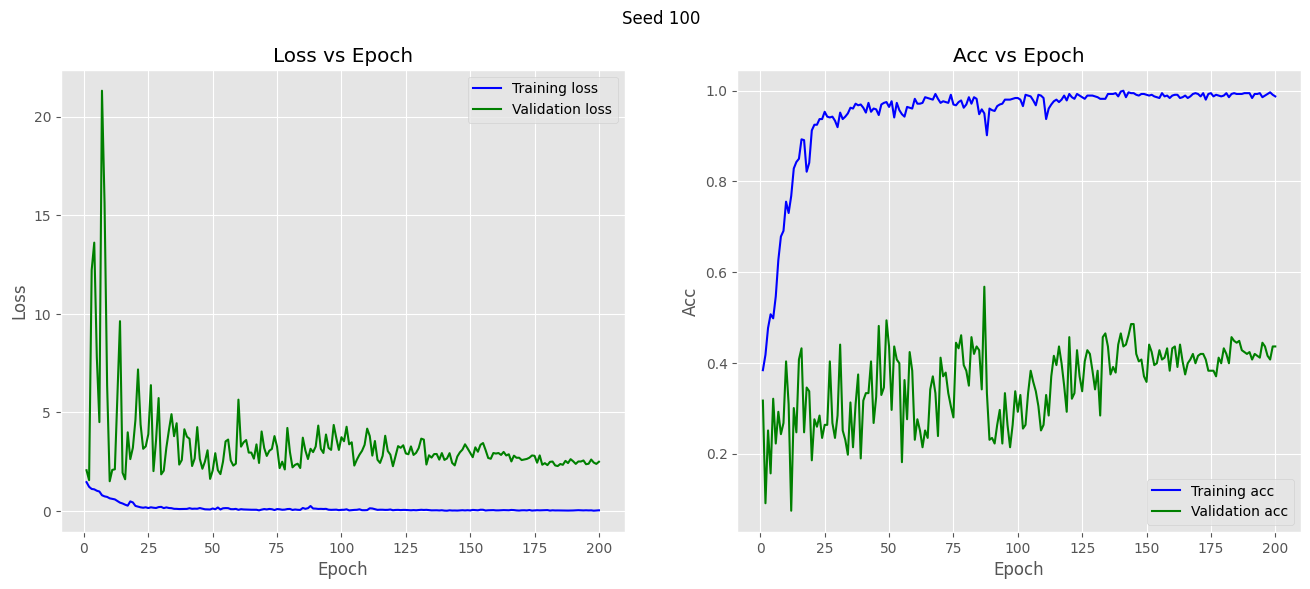

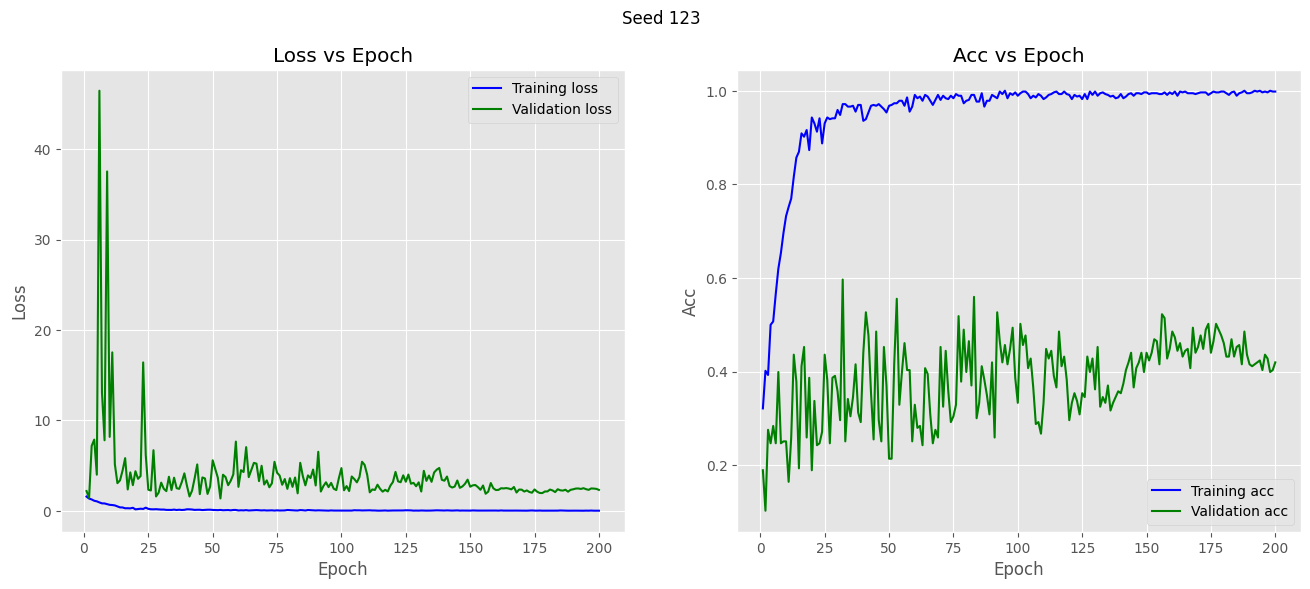

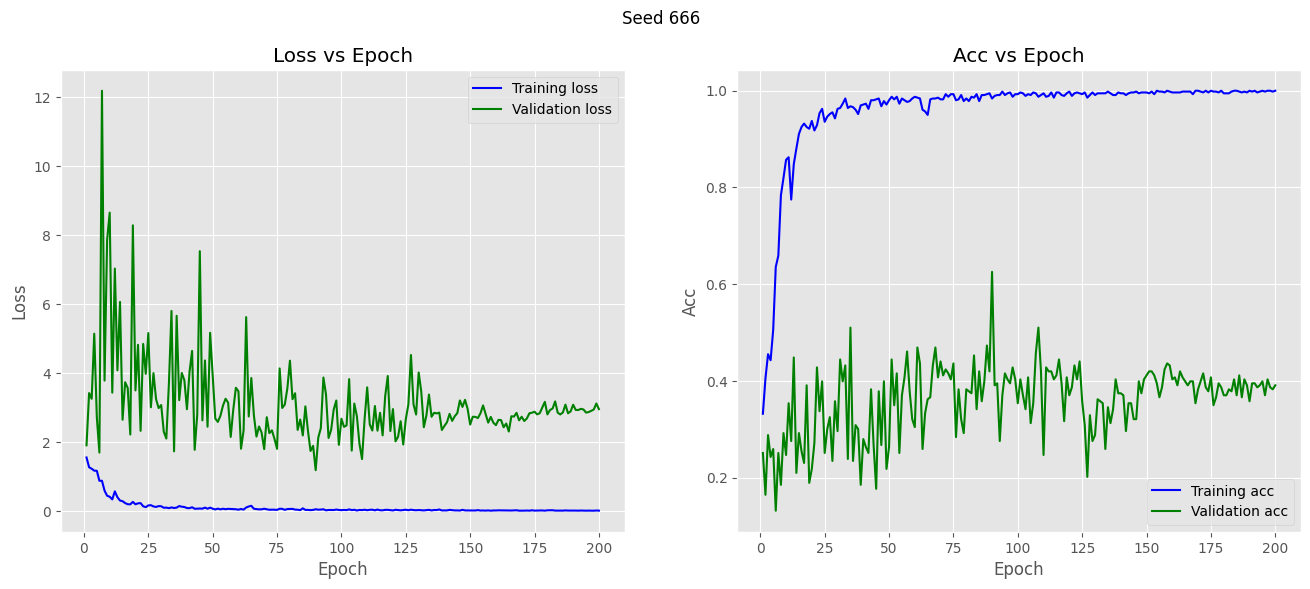

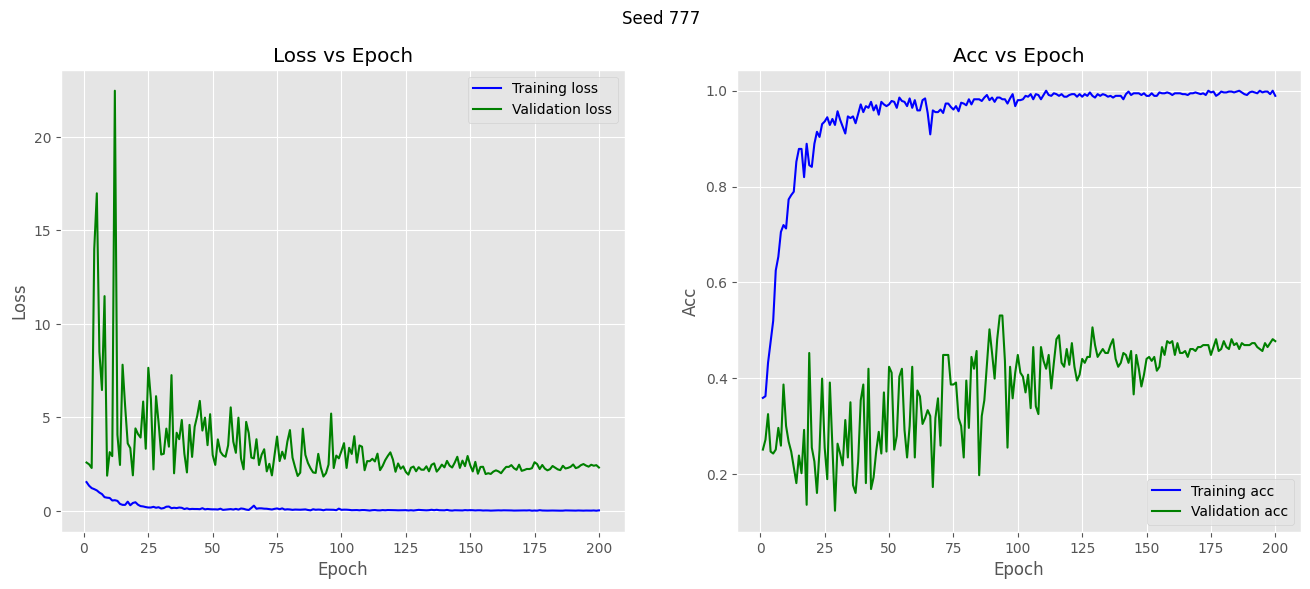

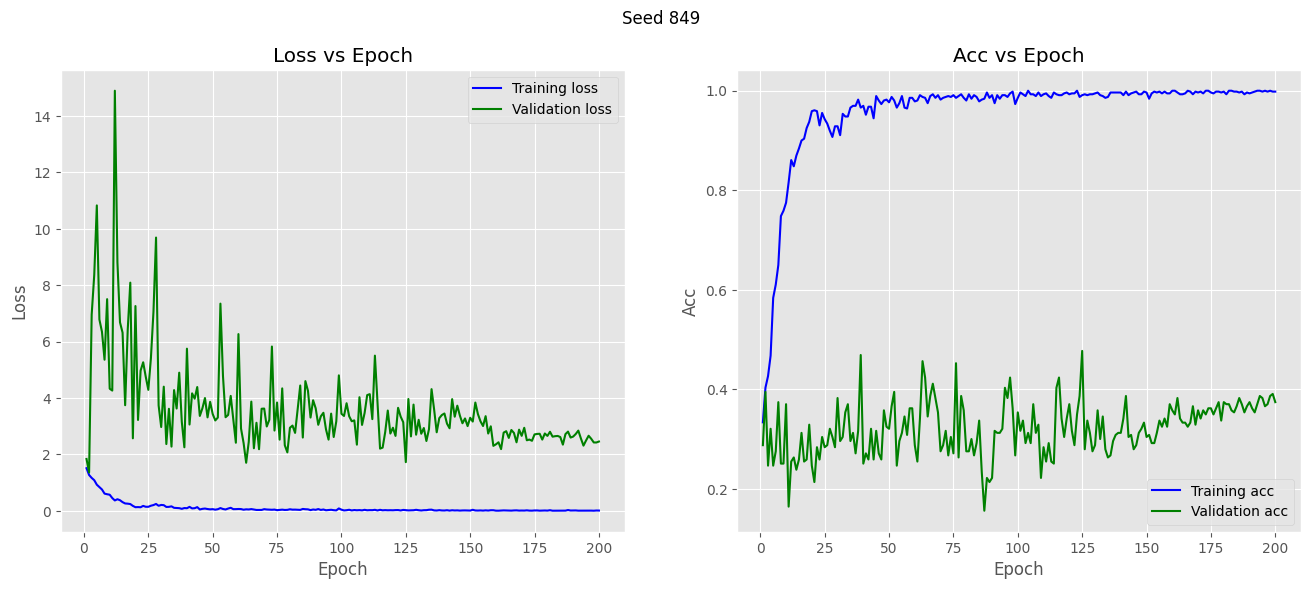

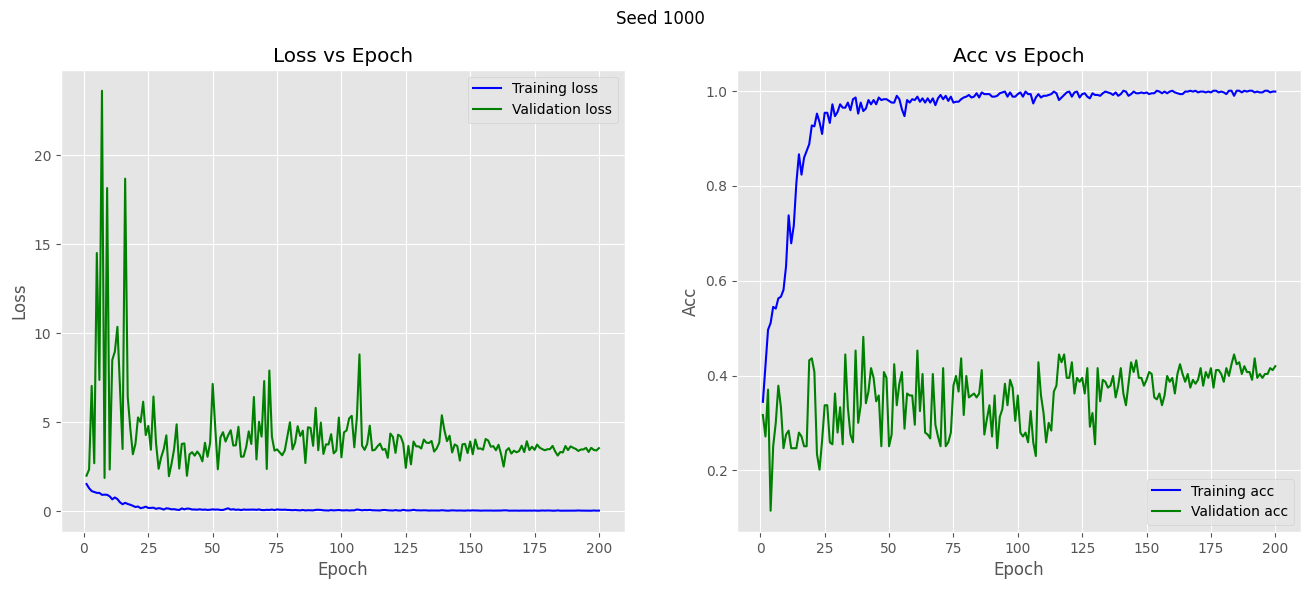

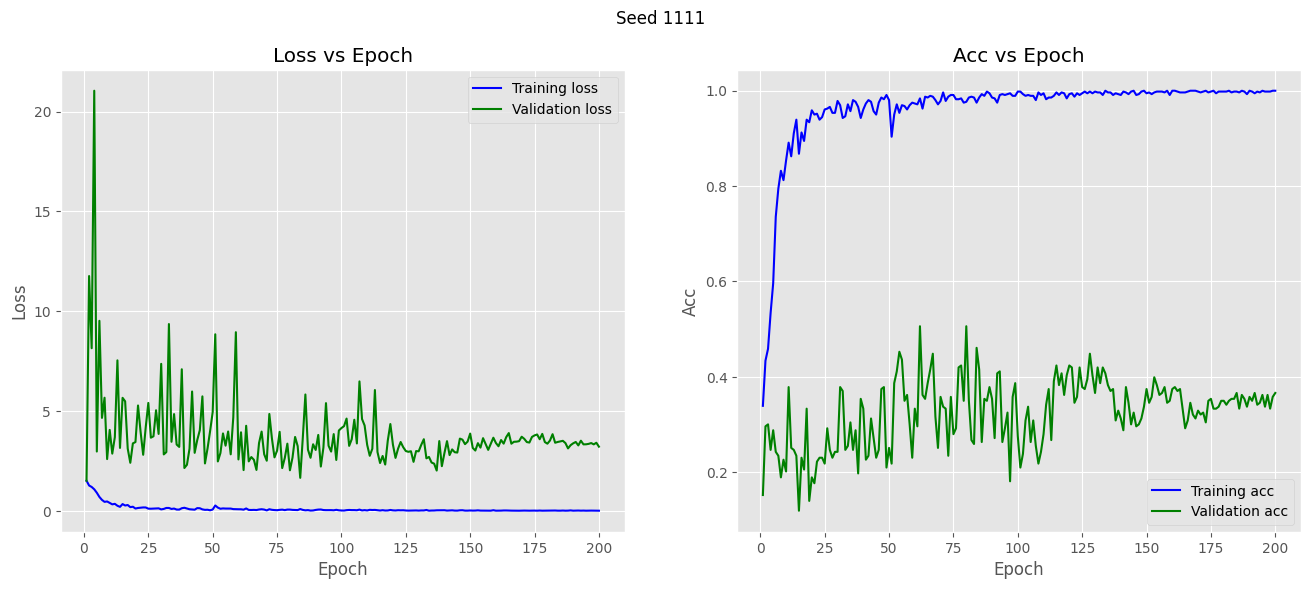

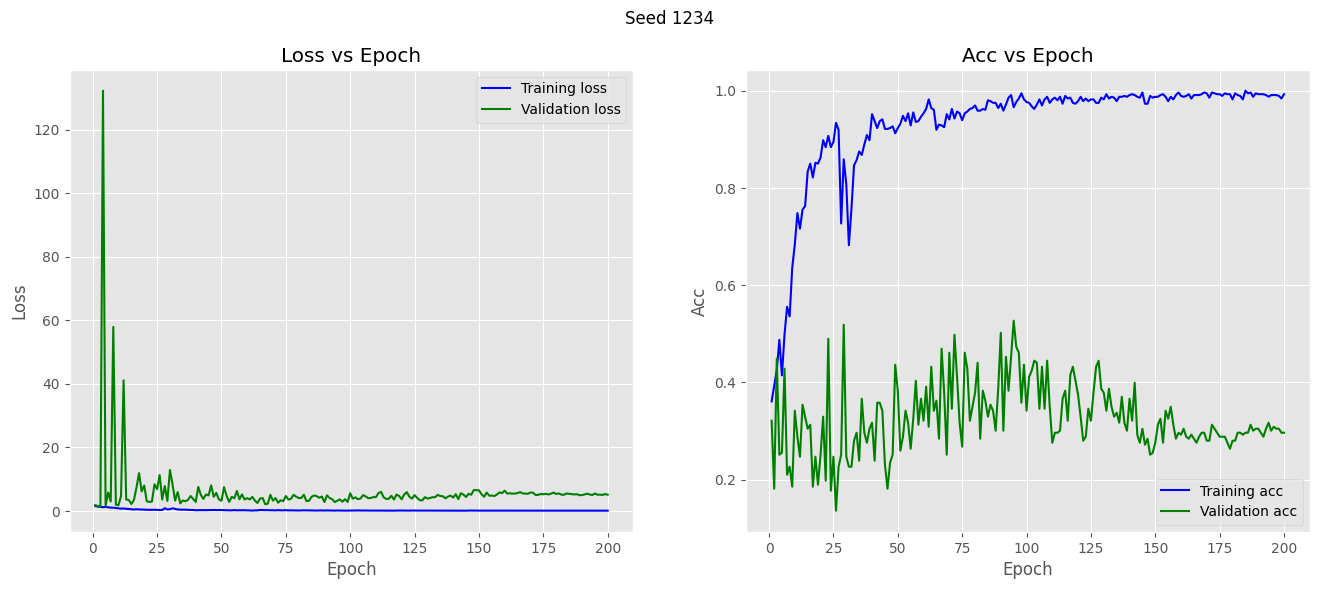

In [42]:
row, col = train_loss.shape

for i, seed in enumerate(seed_lst):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (16, 6))
    
        ax0 = fig.add_subplot(1, 2, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 2, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Acc")
        ax1.legend()
        ax1.grid(True)

        fig.suptitle(f"Seed {seed}")
        plt.show()

In [43]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    get_logits = get_logits_model('LPSLogitLayers')
    pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)
    extras_model = {
        'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
        'conv1_stride': False,
        'maxpool_zpad': False,
        'swap_conv_pool': True,
        'inc_conv1_support': True,
        'apply_maxpool': True,
        'ret_prob': True,
        'forward_pool_method': 'LPS',
    }
    
    new_model = ResNet18Custom(
        input_shape=(3, 128, 128),
        num_classes=len(train_ds.class_to_idx),
        padding_mode='circular',
        pooling_layer=pooling_layer,
        extras_model=extras_model,
    )
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/dso_data/new_data/full_image/SSR_w_noise/rn18_seed{seed}_b16_theirmodel.pth"),
        map_location=device
    ))
    
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {100*test_acc:.4f}")
    test_acc_lst.append(test_acc)

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0: Seed 10
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Test Accuracy: 32.4786
Evaluating Run 1: Seed 42
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Test Accuracy: 47.8632
Evaluating Run 2: Seed 100
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Test Accuracy: 39.3162
Evaluating Run 3: Seed 123
[ResNet18Custom] self.maxpool_

[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)


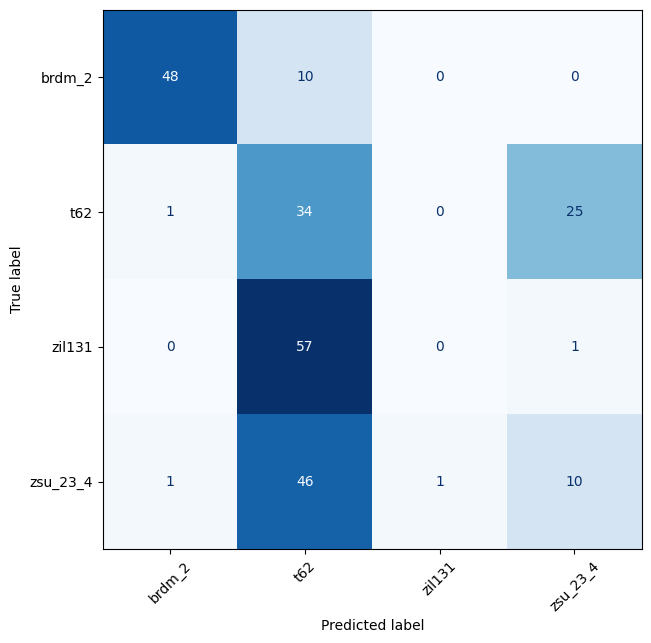

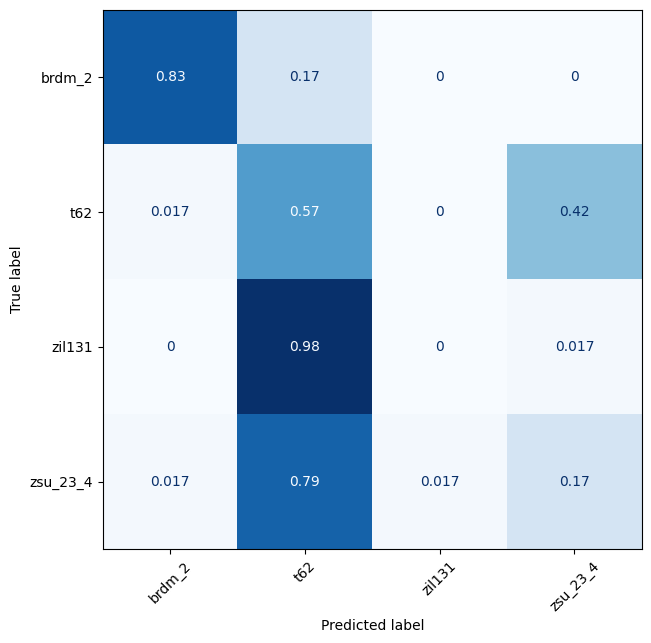

In [44]:
test_dataloader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

seed = 100
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

get_logits = get_logits_model('LPSLogitLayers')
pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)
extras_model = {
    'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
    'conv1_stride': False,
    'maxpool_zpad': False,
    'swap_conv_pool': True,
    'inc_conv1_support': True,
    'apply_maxpool': True,
    'ret_prob': True,
    'forward_pool_method': 'LPS',
}

new_model = ResNet18Custom(
    input_shape=(3, 128, 128),
    num_classes=len(train_ds.class_to_idx),
    padding_mode='circular',
    pooling_layer=pooling_layer,
    extras_model=extras_model,
)
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/dso_data/new_data/full_image/SSR_w_noise/rn18_seed{seed}_b16_theirmodel.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

n_test = len(test_ds)
labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        bs = inputs.size(0)
        labels_tensor[idx:idx+bs] = labels
        preds_tensor[idx:idx+bs] = preds
        idx += bs

_labels_all = labels_tensor.cpu().numpy()
_preds_all = preds_tensor.cpu().numpy()

cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu = cp.asnumpy(cm)
disp = ConfusionMatrixDisplay(cm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.tick_params(axis='x', rotation=45)
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize='true')
cm_norm_cpu = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.tick_params(axis='x', rotation=45)
plt.show()